In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [18]:
URL_SMS = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(URL_SMS, sep="\t", header=None, names=["label", "message"])

print(df.shape)
print(df["label"].value_counts())
df.head()

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


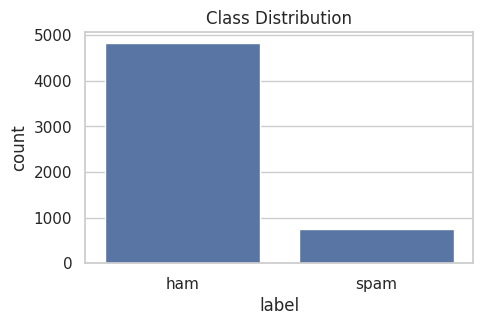

label
ham     0.866
spam    0.134
Name: proportion, dtype: float64


In [19]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.show()

print(df["label"].value_counts(normalize=True).round(3))

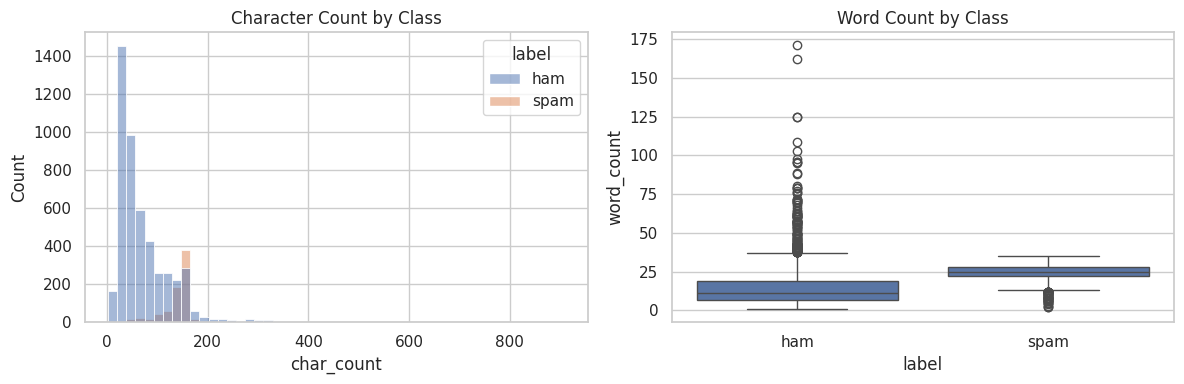

       char_count  word_count
label                        
ham          52.0        11.0
spam        149.0        25.0


In [20]:
df["char_count"] = df["message"].str.len()
df["word_count"] = df["message"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="char_count", hue="label", bins=50, ax=axes[0])
axes[0].set_title("Character Count by Class")
sns.boxplot(data=df, x="label", y="word_count", ax=axes[1])
axes[1].set_title("Word Count by Class")
plt.tight_layout()
plt.show()

print(df.groupby("label")[["char_count", "word_count"]].median().to_string())

In [21]:
df["num_digits"] = df["message"].str.count(r"\d")
df["num_upper"] = df["message"].str.count(r"[A-Z]")
df["has_url"] = df["message"].str.contains(r"http|www", case=False).astype(int)
df["num_exclaim"] = df["message"].str.count("!")

print(df.groupby("label")[["num_digits", "num_upper", "has_url", "num_exclaim"]].mean().round(2).to_string())

       num_digits  num_upper  has_url  num_exclaim
label                                             
ham          0.31       4.10     0.00         0.18
spam        15.81      15.47     0.14         0.73


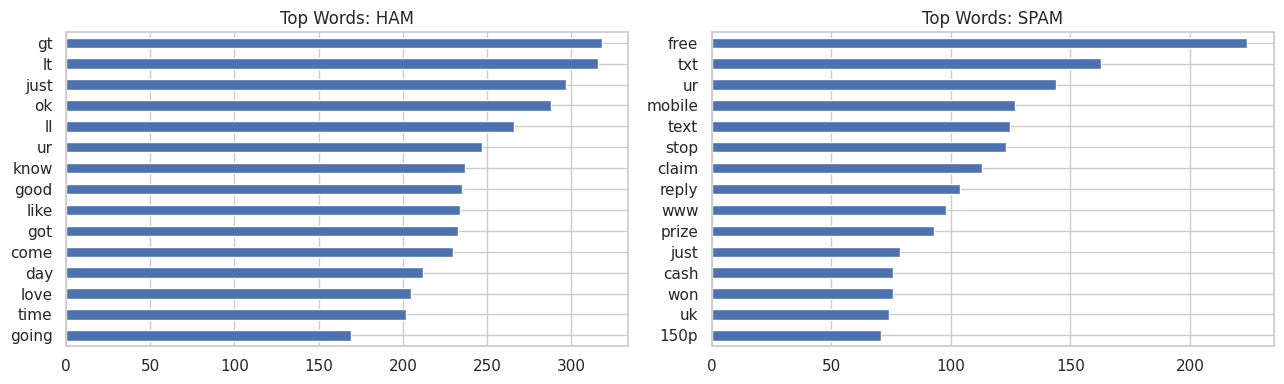

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

def top_words(texts, n=15):
    vec = CountVectorizer(stop_words="english", lowercase=True)
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    return pd.Series(counts, index=vec.get_feature_names_out()).nlargest(n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
top_words(df[df["label"] == "ham"]["message"]).sort_values().plot(kind="barh", ax=axes[0], title="Top Words: HAM")
top_words(df[df["label"] == "spam"]["message"]).sort_values().plot(kind="barh", ax=axes[1], title="Top Words: SPAM")
plt.tight_layout()
plt.show()

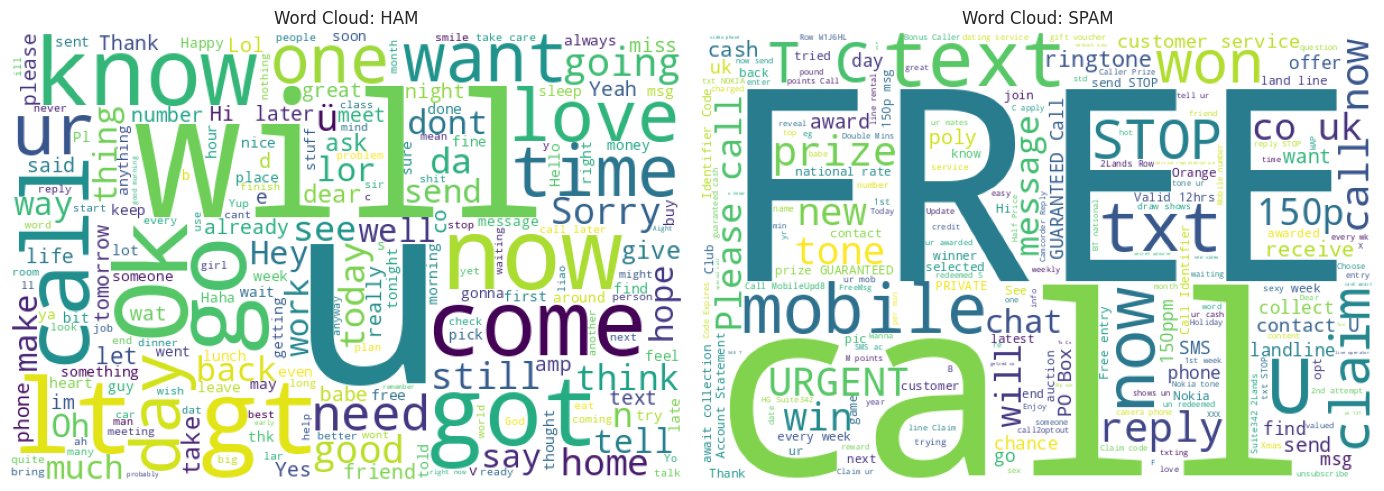

In [23]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lbl in zip(axes, ["ham", "spam"]):
    wc = WordCloud(width=600, height=400, background_color="white",
                   stopwords=None).generate(" ".join(df[df["label"] == lbl]["message"]))
    ax.imshow(wc)
    ax.axis("off")
    ax.set_title(f"Word Cloud: {lbl.upper()}")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df["message"], (df["label"] == "spam").astype(int),
    test_size=0.2, random_state=42, stratify=df["label"]
)

# BASELINE: raw text, default BoW, no cleaning
bow = CountVectorizer()
X_train_base = bow.fit_transform(X_train_txt)
X_test_base = bow.transform(X_test_txt)

nb_base = MultinomialNB()
nb_base.fit(X_train_base, y_train)
pred_base = nb_base.predict(X_test_base)

acc_base = accuracy_score(y_test, pred_base)
f1_base = f1_score(y_test, pred_base)
print(f"BASELINE  ->  Accuracy: {acc_base:.4f} | F1 (spam): {f1_base:.4f}")

BASELINE  ->  Accuracy: 0.9874 | F1 (spam): 0.9514


In [25]:
import re
import html

def clean_text(text):
    text = html.unescape(text)                      # fix &gt; &lt; found in EDA
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " urltoken ", text)
    text = re.sub(r"\d{5,}", " phonetoken ", text)   # phone numbers / shortcodes
    text = re.sub(r"\d+", " numtoken ", text)        # other numbers
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["message"].apply(clean_text)

print(df.loc[2, "message"])
print("->", df.loc[2, "clean"])

Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
-> free entry in numtoken a wkly comp to win fa cup final tkts numtoken st may numtoken text fa to phonetoken to receive entry question std txt rate t c s apply phonetoken over numtoken s


In [26]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import MaxAbsScaler

X_train_c, X_test_c = df.loc[X_train_txt.index, "clean"], df.loc[X_test_txt.index, "clean"]

# TF-IDF with bigrams
tfidf = TfidfVectorizer(ngram_range=(1, 2), stop_words="english", min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train_c)
X_test_tfidf = tfidf.transform(X_test_c)

# Manual features from EDA (computed on the ORIGINAL message, before cleaning)
manual_cols = ["char_count", "num_digits", "num_upper", "num_exclaim", "has_url"]

scaler = MaxAbsScaler()   # keeps sparsity, scales to [0, 1]
X_train_man = csr_matrix(scaler.fit_transform(
    df.loc[X_train_txt.index, manual_cols].values.astype(float)))
X_test_man = csr_matrix(scaler.transform(
    df.loc[X_test_txt.index, manual_cols].values.astype(float)))

# Combine AFTER scaling
X_train_fe = hstack([X_train_tfidf, X_train_man])
X_test_fe = hstack([X_test_tfidf, X_test_man])

print(f"Baseline features : {X_train_base.shape[1]:,}")
print(f"Engineered features: {X_train_fe.shape[1]:,} (TF-IDF bigram + 5 manual)")

Baseline features : 7,668
Engineered features: 7,066 (TF-IDF bigram + 5 manual)


In [27]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_fe, y_train)
pred_fe = logreg.predict(X_test_fe)

acc_fe = accuracy_score(y_test, pred_fe)
f1_fe = f1_score(y_test, pred_fe)
print(f"ENGINEERED  ->  Accuracy: {acc_fe:.4f} | F1 (spam): {f1_fe:.4f}")
print()
print(classification_report(y_test, pred_fe, target_names=["ham", "spam"]))

ENGINEERED  ->  Accuracy: 0.9794 | F1 (spam): 0.9236

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.91      0.93      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [29]:
from sklearn.pipeline import make_pipeline

def evaluate(name, vec, clf, text_train, text_test, add_manual=False):
    Xtr = vec.fit_transform(text_train)
    Xte = vec.transform(text_test)
    if add_manual:
        Xtr = hstack([Xtr, X_train_man])
        Xte = hstack([Xte, X_test_man])
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    return {
        "Pipeline": name,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "F1 (spam)": round(f1_score(y_test, pred), 4),
    }

results = []

# 1. Baseline: raw text, BoW, NB
results.append(evaluate("1. Raw + BoW + NB",
    CountVectorizer(), MultinomialNB(), X_train_txt, X_test_txt))

# 2. Isolate cleaning effect (same vectorizer, same model)
results.append(evaluate("2. Clean + BoW + NB",
    CountVectorizer(), MultinomialNB(), X_train_c, X_test_c))

# 3. Add bigrams (NO stopword removal)
results.append(evaluate("3. Clean + BoW bigram + NB",
    CountVectorizer(ngram_range=(1, 2), min_df=2), MultinomialNB(), X_train_c, X_test_c))

# 4. TF-IDF without stopword removal
results.append(evaluate("4. Clean + TF-IDF bigram + NB",
    TfidfVectorizer(ngram_range=(1, 2), min_df=2), MultinomialNB(), X_train_c, X_test_c))

# 5. Same as 4 but with manual features (NB ok: all non-negative)
results.append(evaluate("5. Clean + TF-IDF bigram + manual + NB",
    TfidfVectorizer(ngram_range=(1, 2), min_df=2), MultinomialNB(),
    X_train_c, X_test_c, add_manual=True))

# 6. LogReg version (the one we had, minus stopword removal)
results.append(evaluate("6. Clean + TF-IDF bigram + manual + LogReg",
    TfidfVectorizer(ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_train_c, X_test_c, add_manual=True))

pd.DataFrame(results)

,Pipeline,Accuracy,F1 (spam)
0,1. Raw + BoW + NB,0.9874,0.9514
1,2. Clean + BoW + NB,0.9883,0.9559
2,3. Clean + BoW bigram + NB,0.9874,0.9527
3,4. Clean + TF-IDF bigram + NB,0.9740,0.8922
4,5. Clean + TF-IDF bigram + manual + NB,0.9812,0.9242
5,6. Clean + TF-IDF bigram + manual + LogReg,0.9857,0.9463
